In [112]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [113]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]
FEATURES_TO_CONSIDER = torch.arange(29)

KEEP_ONLY_COORDS = False

In [114]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [115]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (33.29377413364008, 24.98689330720664)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.27it/s]


In [116]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001].reshape(-1, 1001)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [117]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])
dataset_std = torch.ones_like(dataset_std)

def normalize_dataset_coords(dataset_, features_to_consider_only=False):
    # return dataset_    
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = (dataset - dataset_mean.to(dataset.device)) / dataset_std.to(dataset.device)
    else:
        dataset = (dataset - dataset_mean[FEATURES_TO_CONSIDER]) / dataset_std[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

# def denormalize_dataset_coords(dataset_, features_to_consider_only=False):
#     # return dataset_
#     is_numpy = isinstance(dataset_, np.ndarray)
#     if is_numpy: dataset_ = torch.tensor(dataset_)
#     dataset = dataset_.clone()
#     if not features_to_consider_only:
#         dataset = dataset * dataset_std + dataset_mean
#     else:
#         dataset = dataset * dataset_std[FEATURES_TO_CONSIDER] + dataset_mean[FEATURES_TO_CONSIDER]
#     if is_numpy: dataset = np.array(dataset.cpu())
#     return dataset

# dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [118]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [119]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )


    def get_transformer_encoding(self, reward_state_pairs):
        reward_states = reward_state_pairs[:, :, :-1]
        reward_values = reward_state_pairs[:, :, -1]
        reward_values_idx = torch.floor((reward_values / 2.0 + 0.5) * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        reward_state_emb = self.state_embed(reward_states)
        reward_state_val = self.reward_embed(reward_values_idx)
        
        reward_state_pairs = torch.concatenate([reward_state_emb, reward_state_val], axis=-1)

        w_pre = self.encoder_transformer(reward_state_pairs) # [batch, reward_pairs, emb_dim]
        
        w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# Reward Generator:

In [120]:
EPISODE_LENGTH = TRAJECTORY_LEN
Z_DIM = 128
MIN_NUM_ANCHORS = 2
MAX_NUM_ANCHORS = 8

In [121]:
from utils.reward_alignement import RNDModule, RNDResampling

In [122]:
class RewardGeneratorTransformer(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        # self.encoder_mask = nn.Sequential(
        #     nn.Linear(self.reward_pairs_emb_dim, 512),
        #     nn.ReLU(),
        #     nn.Linear(512, 512),
        #     nn.ReLU(),
        #     nn.Linear(512, self.obs_len),
        #     nn.Sigmoid()
        # )

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
            nn.Tanh()
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        mask = (states != 0).float()
        states = normalize_dataset_coords(states)
        states = states * mask
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)
        # predicted_mask = self.encoder_mask(w_pair_mean)
        predicted_mask = None
        
        return w_mean, w_log_std, predicted_mask # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
                        
        mask = (reward_states != 0).float()
        reward_states = normalize_dataset_coords(reward_states)
        reward_states = reward_states * mask
        
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]

In [123]:
class RewardGenerator:
    def __init__(self, fre_network: RewardGeneratorTransformer):
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.len_params = Z_DIM
        self.resampling_weights = None
        
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors):
        assert min_num_anchors <= max_num_anchors

        obs_dim = dataset_trajectories.shape[-1]
        

        # buffer = dataset_trajectories[..., :2].reshape(-1, 2)
        # buffer = dataset_trajectories
        
        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)

        # idx = self.get_importance_sampling_indices(batch_size*max_num_anchors,)
        # anchors = buffer[idx, :2]
        
        trajectories_idx = torch.randint(0, num_trajectories, (batch_size*max_num_anchors,))
        states_idx = torch.randint(0, 100, (batch_size*max_num_anchors,))
        anchors = dataset_trajectories[trajectories_idx, states_idx]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)

            
        anchors_rewards = torch.zeros((batch_size, max_num_anchors), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)

        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))

        reward_indices = torch.arange(max_num_anchors).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)

        
        # candidates = torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.])
        
        reward_types = torch.ones((batch_size,), dtype=torch.long) # 0: goal reaching | 1: MLP
        
        candidates = [
            # torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.]),
            torch.tensor([-1, -0.5, 0.0, 0.5, 1.]),
            # torch.tensor([-1, -0.75, -0.5, -0.25, 0.0]),
            # torch.tensor([0.0, 0.25, 0.5, 0.75, 1.]),
        ]
        res = []
        for b in range(batch_size):
            x = torch.randint(0, len(candidates), (1,))
            res.append(candidates[x][torch.randint(0, candidates[x].shape[0], (max_num_anchors,))])
        anchors_rewards = torch.stack(res)
        
        # anchors_rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (reward_mask.sum(),))]
        
        # Goal reaching reward functions:
        random_rows = torch.tensor([n for n in range(batch_size) if random.random() < 0.3], dtype=torch.long)
        anchors_rewards[random_rows] = -1.
        anchors_rewards[random_rows, 0] = 1.
        reward_types[random_rows] = 0

            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        anchors_rewards = anchors_rewards.unsqueeze(-1)

        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
                
        
        anchors = anchors[..., FEATURES_TO_CONSIDER].float()
        anchors_rewards = anchors_rewards.float()
        pad_mask = pad_mask
        
        return (anchors, anchors_rewards, pad_mask), {'reward_types':reward_types}
    

    def generate_boolean_mask(self, batch_size, length, p=0.9):
        vecs = (torch.rand(batch_size, length) > p).bool()
        mask = ~vecs.any(dim=1)
        if mask.any():
            rows = mask.nonzero(as_tuple=False).squeeze(1)
            cols = torch.randint(0, length, (rows.size(0),))
            vecs[rows, cols] = True
        
        
        if KEEP_ONLY_COORDS:
            vecs = torch.zeros_like(vecs)
            vecs[:, :2] = True
            
        return vecs * 1.
    
        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.5)
        # mask = torch.zeros_like(mask)
        # mask[..., [0, 1]] = 1

        # Only keep coords for goal reaching rewards (reward_types == 0):
        # mask[info['reward_types'] == 0, :2] = 1
        # mask[info['reward_types'] == 0, 2:] = 0


        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
                                

        w_mean, w_log_std, predicted_mask = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, anchors)
        
        
        reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info,
            'anchors': anchors.cpu(),
            'anchors_rewards': anchors_rewards.cpu(),
            'pad_mask': pad_mask.cpu(),
        }
        
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, mask=None):
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        if mask is None:
            mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.0)
        
        assert mask.shape == (batch_size, len(FEATURES_TO_CONSIDER))
        
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {
            'anchors': anchors.cpu(), 
            'anchors_rewards': anchors_rewards.cpu(), 
            'pad_mask': pad_mask.cpu(), 
            'get_training_data:info': info
        }
    

    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std, predicted_mask = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu(), 'predicted_mask': predicted_mask}
            
    
    def get_importance_sampling_indices(self, N):
        indices = torch.multinomial(self.resampling_weights, N, replacement=True)
        return indices

---

In [124]:
class MaskPredictorTransformer(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )

        self.encoder_mask = nn.Sequential(
            nn.Linear(self.reward_pairs_emb_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, self.obs_len),
            nn.Sigmoid()
        )

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)



    def get_predicted_mask(self, states, rewards, pad_mask=None):  
        
        mask = (states != 0).float()
        states = normalize_dataset_coords(states)
        states = states * mask
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        predicted_mask = self.encoder_mask(w_pair_mean)
        
        return predicted_mask # (batch_size, emb_dim)

---

In [125]:
num_anchors = 8

rg_model = RewardGeneratorTransformer(obs_len=obs_dim)
# rg_model.load_state_dict(torch.load('models/all_in_one-coords-rg_model.pth'))
rg_model.load_state_dict(torch.load('shared_models/offline_fre+reward_generator-rg_model.pth'))

reward_generator = RewardGenerator(
    fre_network=rg_model,
)



vae_loss, vae_kl_loss = [], []

/tmp/ipykernel_6904/3457169219.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rg_model.load_state_dict(torch.load('shared_models/offline_fre+reward_generator-rg_model.p

In [126]:
print('VAE training...')
for step in tqdm(range(15_000), desc='VAE training', leave=False):
    
    vae_loss_dict = reward_generator.train_step_VAE(
        batch_size=256,
        min_num_anchors=MIN_NUM_ANCHORS,
        max_num_anchors=MAX_NUM_ANCHORS,
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
    break
    
    if step % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        axs[0].set_ylim([0, 0.5])
        # axs[0].set_xscale('log')
        axs[1].plot(vae_kl_loss)
        axs[1].set_ylim([0, 1])
        plt.show()
    
    break
        

VAE training...


In [127]:
def visualize_rewards_and_trajectories(eval_z, reward_generator, anchors=None, anchors_rewards=None, pad_mask=None, mask=None):

    state = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    state = state.to(device)


    num_evals = eval_z.shape[0]
    num_rows = int(np.floor(num_evals/4))
    num_rows += 1 if (num_rows == 0) or num_evals % (num_rows*4) != 0 else 0
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, num_rows*4))
    axs = axs.flatten()
    
    
    if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
        anchors_rewards = anchors_rewards * 0.5 + 0.5
        anchors_rewards = anchors_rewards.clip(0, 1)
        anchors_rewards = anchors_rewards * 20
        anchors_rewards = anchors_rewards + 0.1
                
        anchors = np.where(~pad_mask[..., None], anchors, None)
        anchors_rewards = np.where(~pad_mask[..., None], anchors_rewards, 0)
        
        

    for i in range(len(eval_z)):
        
        
        
        zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
        with torch.no_grad():
            x = state[..., FEATURES_TO_CONSIDER]
            if mask is not None:
                x = x * mask[i].unsqueeze(0).repeat(state.shape[0], 1).to(device)
            # x = torch.zeros_like(x)
                        
            r = reward_generator.get_reward(x, zi).cpu()
        
        
        axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.7, s=20, vmin=-1, vmax=1)
        
        if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
            axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c='red', s=anchors_rewards[i, :, 0].reshape(-1))
    

    return fig, axs, {'state':state.cpu(), 'r':r.cpu()} 
    # plt.show()

tensor([1])


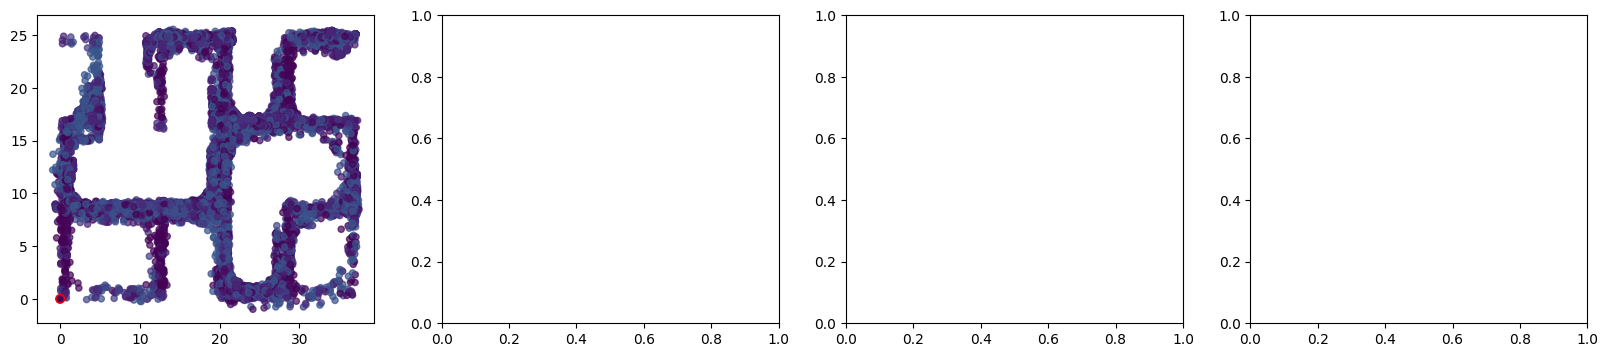

In [128]:
eval_num_envs = 1
num_anchors = 2

mask = reward_generator.generate_boolean_mask(eval_num_envs, len(FEATURES_TO_CONSIDER), p=0.5)
mask = torch.zeros_like(mask)
# mask[..., [0, 1, 15, 16]] = 1.
# mask[..., [0, 1]] = 1.
mask[..., [15, 16]] = 1.
# mask[..., [3, 4]] = 1.
# mask = None

with torch.no_grad():
    w, z_info = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=num_anchors, max_num_anchors=num_anchors, mask=mask)
print(z_info['get_training_data:info']['reward_types'])    

fig, axs, info = visualize_rewards_and_trajectories(w, reward_generator, mask=mask)
# axs[0].scatter(z_info['anchors'][..., 0].cpu(), z_info['anchors'][..., 1].cpu(), s=(z_info['anchors_rewards'].cpu()+1.01)*50, c='red')
axs[0].scatter(z_info['anchors'][..., 0].cpu(), z_info['anchors'][..., 1].cpu(), c=z_info['anchors_rewards'].cpu(), edgecolors='red', vmin=-1, vmax=1)
# info['anchors_rewards'].flatten()

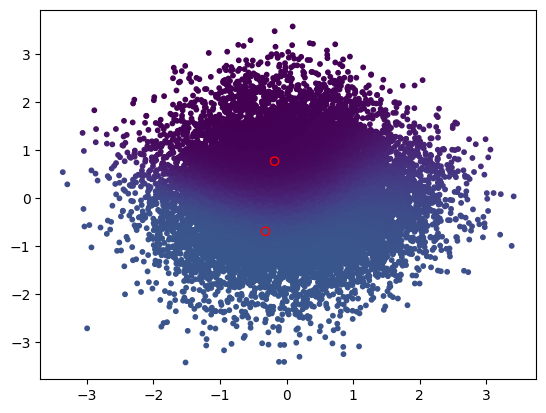

In [129]:
plt.scatter(info['state'][..., 15], info['state'][..., 16], c=info['r'], vmin=-1, vmax=1, s=10)
plt.scatter(z_info['anchors'][..., 15].cpu(), z_info['anchors'][..., 16].cpu(), c=z_info['anchors_rewards'].cpu(), edgecolors='red', vmin=-1, vmax=1)

---
# Mask predicion:

In [130]:
def sample_reward_function_fre(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    # states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, 100, (batch_size*num_random_samples,))

    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, len(FEATURES_TO_CONSIDER)).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))


    # num_anchors = 16
    mask = reward_generator.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.9)
    # mask = torch.zeros_like(mask)
    # mask[..., [0, 1]] = 1
    

    with torch.no_grad():
        reward_params, _ = reward_generator.get_z_from_random_anchors(batch_size, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS, mask=mask)
        
        x = random_states * mask.unsqueeze(1).repeat(1, num_random_samples, 1).to(device)
        
        random_states_rewards = reward_generator.get_reward(
            x.reshape(-1, obs_dim), 
            reward_params.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        ).reshape(batch_size, num_random_samples)
    
    return reward_params, random_states, random_states_rewards, mask

In [131]:
mask_predictor = MaskPredictorTransformer(obs_len=obs_dim).to(device)
# mask_predictor.load_state_dict(torch.load('models/offline_fre-mask_predictor-0.9.pth'))
optimimizer = torch.optim.Adam(mask_predictor.parameters(), lr=0.001)
criterion = nn.BCELoss()

mask_losses = []

In [132]:
num_states = 512

for i in tqdm(range(10_000)):
    
    reward_params, random_states, random_states_rewards, mask = sample_reward_function_fre(batch_size=16, num_random_samples=num_states)
    
    encode_obs = random_states.to(device)
    encode_rewards = random_states_rewards[..., None].to(device)

            
    # encode_rewards, goals = goal_rewards(encode_obs, goals=None)
    # decode_rewards, goals = goal_rewards(decode_obs, goals=goals)
    
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    
    predicted_mask = mask_predictor.get_predicted_mask(
        encode_obs, 
        encode_rewards, 
        pad_mask=None
    )
    
    break
    
    # print(predicted_mask, mask)
    loss = criterion(predicted_mask, mask.to(device))
    
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()
    
    mask_losses.append(loss.item())
    
    if i % 100 == 0:
        clear_output(True)
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        ax.plot(mask_losses)
        # ax.set_ylim(0, 0.5)
        plt.show()
        
    break

  0%|          | 0/10000 [00:00<?, ?it/s]


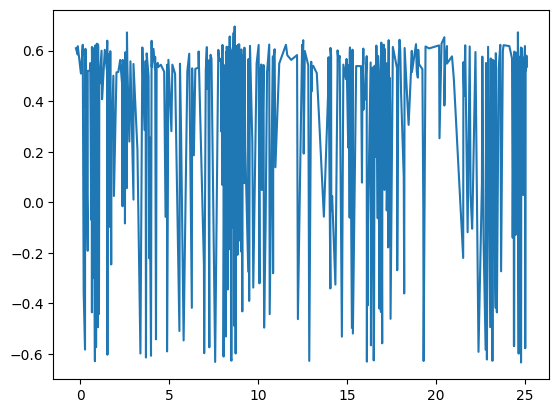

In [133]:

sort_idx = encode_obs[12, :, 1].argsort()

plt.plot(encode_obs[12, :, 1][sort_idx].cpu(), encode_rewards[12][sort_idx].cpu())

0 tensor([0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


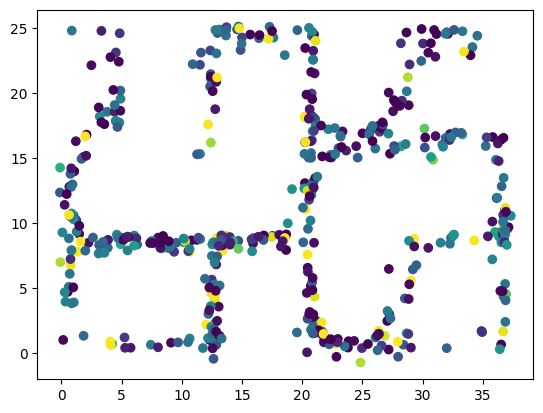

[3.3670198e-03 8.3660884e-03 7.7811247e-03 9.6449716e-04 1.8544471e-02
 2.2316674e-02 6.5484067e-04 4.7481032e-03 5.1929224e-02 1.4955029e-03
 2.2624811e-02 8.7521650e-04 2.6271967e-03 1.3620141e-01 3.2005701e-02
 1.4418989e-02 7.5098872e-03 1.9712672e-03 4.0218364e-03 1.7605844e-01
 1.7031902e-03 3.2583988e-04 1.7260900e-02 8.7541970e-04 4.4580325e-01
 5.3190892e-03 2.6930775e-03 4.6596853e-03 2.8772487e-03]


In [139]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

for i in range(16):
    print(i, mask[i])
    plt.scatter(encode_obs[i, :, 0].cpu(), encode_obs[i, :, 1].cpu(), c=encode_rewards[i].cpu())
    plt.show()
    
    

    model = XGBRegressor()
    model.fit(
        encode_obs[i].cpu().numpy(), 
        encode_rewards[i].cpu().numpy()
    )

    # Feature importance
    importances = model.feature_importances_
    
    print(importances)
    
    
    break

In [141]:
importances.round(2)

array([0.  , 0.01, 0.01, 0.  , 0.02, 0.02, 0.  , 0.  , 0.05, 0.  , 0.02,
       0.  , 0.  , 0.14, 0.03, 0.01, 0.01, 0.  , 0.  , 0.18, 0.  , 0.  ,
       0.02, 0.  , 0.45, 0.01, 0.  , 0.  , 0.  ], dtype=float32)

In [135]:
(predicted_mask > 0.5).float()

tensor([[0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1.,
         1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1.,
         1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.,
         1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1.,
         1., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1.,
         1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1.,
         1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 0.],
        [0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
         1., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1.

In [136]:
(predicted_mask[mask.bool()] > 0.5).float().mean()

tensor(0.4600, device='cuda:0')

In [137]:
for i in range(10):
    n = i / 10
    acc = ((predicted_mask > n).long().cpu() == mask.cpu()).float().mean()
    # acc = (predicted_mask[mask.bool()] > n).float().mean()
    print(n, acc)

0.0 tensor(0.1078)
0.1 tensor(0.1078)
0.2 tensor(0.1078)
0.3 tensor(0.1078)
0.4 tensor(0.1078)
0.5 tensor(0.5345)
0.6 tensor(0.8922)
0.7 tensor(0.8922)
0.8 tensor(0.8922)
0.9 tensor(0.8922)


In [138]:
torch.save(mask_predictor.state_dict(), 'models/offline_fre-mask_predictor-0.9.pth')